<a href="https://colab.research.google.com/github/Tolureis/CMPE-460-Deep-Learning/blob/main/Stochastic_Gradient_Descent_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

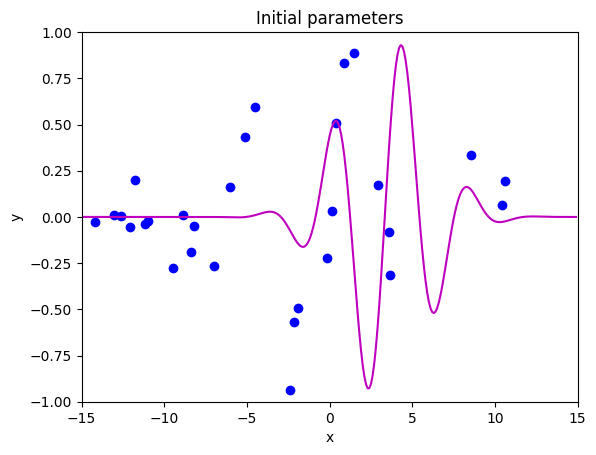

Your loss = 16.419, Correct loss = 16.419


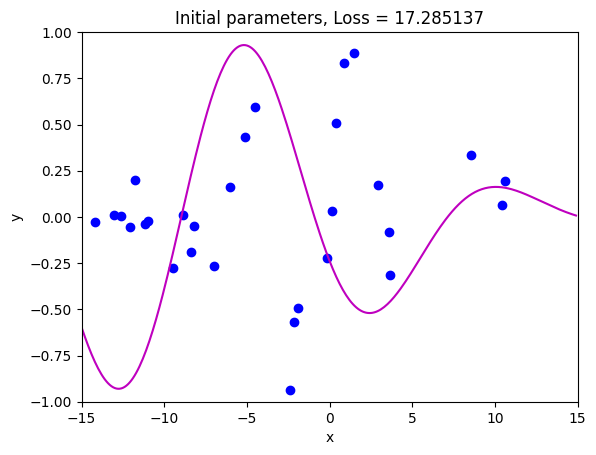

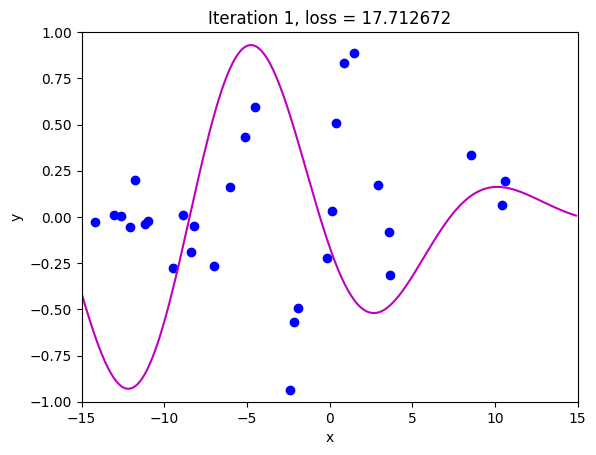

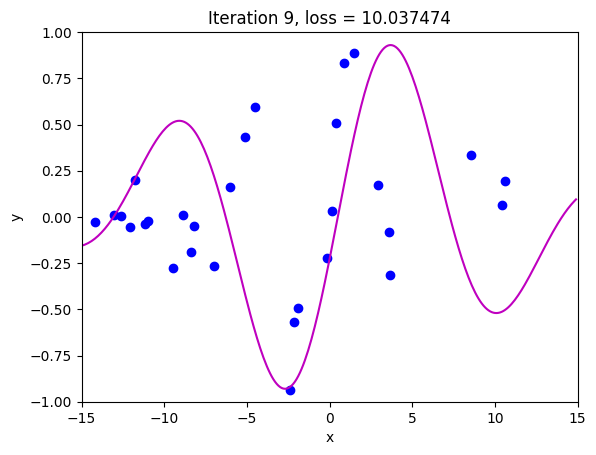

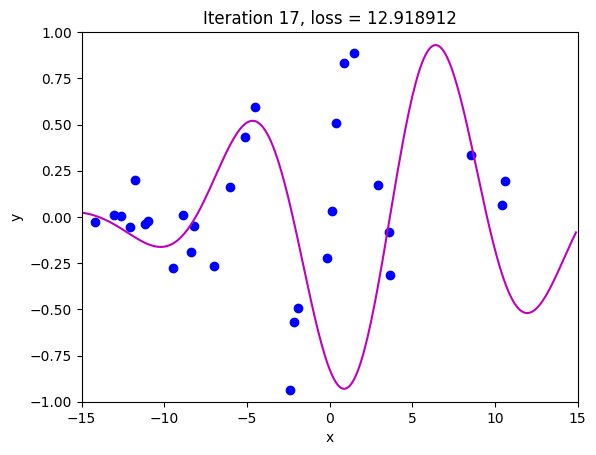

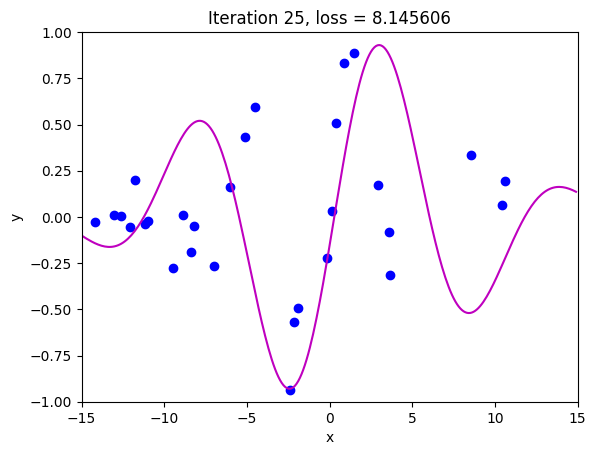

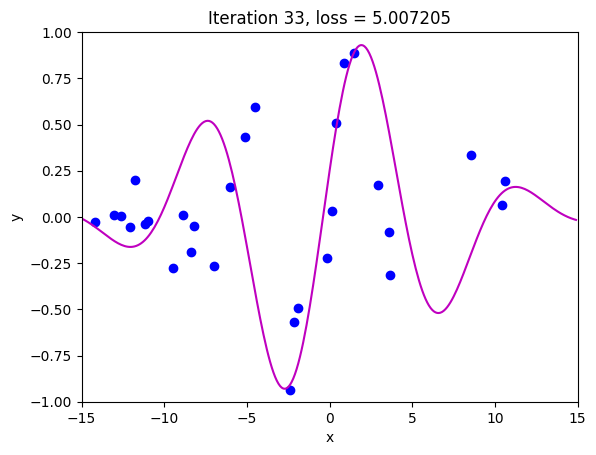

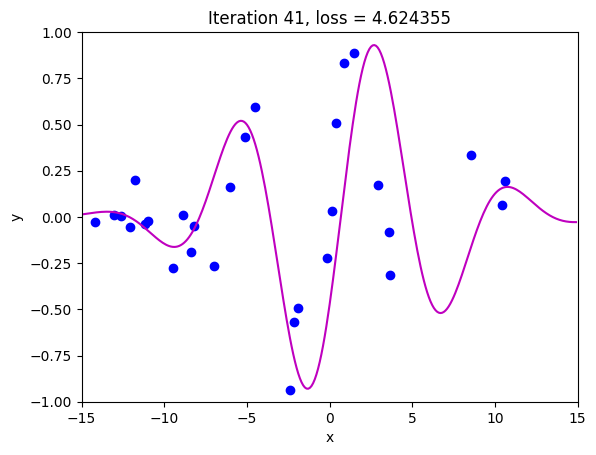

In [ ]:

"""6_3_Stochastic_Gradient_Descent.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/github/udlbook/udlbook/blob/main/Notebooks/Chap06/6_3_Stochastic_Gradient_Descent.ipynb

# **Notebook 6.3: Stochastic gradient descent**

This notebook investigates gradient descent and stochastic gradient descent and recreates figure 6.5 from the book

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.
"""

# -*- coding: utf-8 -*-
"""6_3_Stochastic_Gradient_Descent.ipynb"""

# import libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap

# Let's create our training data of 30 pairs {x_i, y_i}
data = np.array([[-1.920e+00,-1.422e+01,1.490e+00,-1.940e+00,-2.389e+00,-5.090e+00,
                 -8.861e+00,3.578e+00,-6.010e+00,-6.995e+00,3.634e+00,8.743e-01,
                 -1.096e+01,4.073e-01,-9.467e+00,8.560e+00,1.062e+01,-1.729e-01,
                  1.040e+01,-1.261e+01,1.574e-01,-1.304e+01,-2.156e+00,-1.210e+01,
                 -1.119e+01,2.902e+00,-8.220e+00,-1.179e+01,-8.391e+00,-4.505e+00],
                  [-1.051e+00,-2.482e-02,8.896e-01,-4.943e-01,-9.371e-01,4.306e-01,
                  9.577e-03,-7.944e-02 ,1.624e-01,-2.682e-01,-3.129e-01,8.303e-01,
                  -2.365e-02,5.098e-01,-2.777e-01,3.367e-01,1.927e-01,-2.222e-01,
                  6.352e-02,6.888e-03,3.224e-02,1.091e-02,-5.706e-01,-5.258e-02,
                  -3.666e-02,1.709e-01,-4.805e-02,2.008e-01,-1.904e-01,5.952e-01]])

# Let's define our model
def model(phi,x):
  sin_component = np.sin(phi[0] + 0.06 * phi[1] * x)
  gauss_component = np.exp(-(phi[0] + 0.06 * phi[1] * x) * (phi[0] + 0.06 * phi[1] * x) / 32)
  y_pred= sin_component * gauss_component
  return y_pred

# Draw model
def draw_model(data,model,phi,title=None):
  x_model = np.arange(-15,15,0.1)
  y_model = model(phi,x_model)

  fix, ax = plt.subplots()
  ax.plot(data[0,:],data[1,:],'bo')
  ax.plot(x_model,y_model,'m-')
  ax.set_xlim([-15,15]);ax.set_ylim([-1,1])
  ax.set_xlabel('x'); ax.set_ylabel('y')
  if title is not None:
    ax.set_title(title)
  plt.show()

# Initialize the parameters and draw the model
phi = np.zeros((2,1))
phi[0] =  -5
phi[1] =  25
draw_model(data,model,phi, "Initial parameters")

# === COMPLETE compute_loss ===
def compute_loss(data_x, data_y, model, phi):
  y_pred = model(phi, data_x)
  loss = np.sum((y_pred - data_y)**2)
  return loss

# Test loss
loss = compute_loss(data[0,:],data[1,:],model,np.array([[0.6],[-0.2]]))
print('Your loss = %3.3f, Correct loss = %3.3f'%(loss, 16.419))

# draw_loss_function stays unchanged (omitted here for brevity)

# --- Derivative & gradient functions remain unchanged ---
def gabor_deriv_phi0(data_x,data_y,phi0, phi1):
    x = 0.06 * phi1 * data_x + phi0
    y = data_y
    cos_component = np.cos(x)
    sin_component = np.sin(x)
    gauss_component = np.exp(-0.5 * x *x / 16)
    deriv = cos_component * gauss_component - sin_component * gauss_component * x / 16
    deriv = 2* deriv * (sin_component * gauss_component - y)
    return np.sum(deriv)

def gabor_deriv_phi1(data_x, data_y,phi0, phi1):
    x = 0.06 * phi1 * data_x + phi0
    y = data_y
    cos_component = np.cos(x)
    sin_component = np.sin(x)
    gauss_component = np.exp(-0.5 * x *x / 16)
    deriv = 0.06 * data_x * cos_component * gauss_component - 0.06 * data_x*sin_component * gauss_component * x / 16
    deriv = 2*deriv * (sin_component * gauss_component - y)
    return np.sum(deriv)

def compute_gradient(data_x, data_y, phi):
    dl_dphi0 = gabor_deriv_phi0(data_x, data_y, phi[0],phi[1])
    dl_dphi1 = gabor_deriv_phi1(data_x, data_y, phi[0],phi[1])
    return np.array([[dl_dphi0],[dl_dphi1]])

# === COMPLETE gradient_descent_step_fixed_learning_rate ===
def gradient_descent_step_fixed_learning_rate(phi, data, alpha):
  gradient = compute_gradient(data[0,:], data[1,:], phi)
  phi = phi - alpha * gradient
  return phi

# === COMPLETE stochastic_gradient_descent_step ===
def stochastic_gradient_descent_step(phi, data, alpha, batch_size):
  n_data = data.shape[1]
  indices = np.random.permutation(n_data)[:batch_size]
  data_x_batch = data[0, indices]
  data_y_batch = data[1, indices]
  gradient = compute_gradient(data_x_batch, data_y_batch, phi)
  phi = phi - alpha * gradient
  return phi

# Set the random number generator so you always get same numbers (disable if you don't want this)
np.random.seed(1)
# Initialize the parameters
n_steps = 41
phi_all = np.zeros((2,n_steps+1))
phi_all[0,0] = 3.5
phi_all[1,0] = 6.5

# Measure loss and draw initial model
loss =  compute_loss(data[0,:], data[1,:], model, phi_all[:,0:1])
draw_model(data,model,phi_all[:,0:1], "Initial parameters, Loss = %f"%(loss))

for c_step in range (n_steps):
  # Do gradient descent step
  phi_all[:,c_step+1:c_step+2] = stochastic_gradient_descent_step(phi_all[:,c_step:c_step+1],data, alpha =0.8, batch_size=5)
  # Measure loss and draw model every 8th step
  if c_step % 8 == 0:
    loss =  compute_loss(data[0,:], data[1,:], model, phi_all[:,c_step+1:c_step+2])
    draw_model(data,model,phi_all[:,c_step+1], "Iteration %d, loss = %f"%(c_step+1,loss))

# draw_loss_function(compute_loss, data, model,phi_all)

# TODO -- Experiment with different learning rates, starting points, batch sizes, number of steps.  Get a feel for this.

# TODO -- Add a learning rate schedule.  Reduce the learning rate by a factor of beta every M iterations